In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

import methods as meth

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_hourly_yearly_profiles(BZN: str, mode: str = 'prices'):
    """
    For the given BZN and mode (‘prices’ or ‘loads’), plots 24 subplots (3 cols × 8 rows).
    Each subplot shows, for one hour-of-day, how that hour’s Day-ahead Price (or Load)
    evolves across the days of the year—overlaid for each year in shades of gray.
    """
    assert mode in ('prices', 'loads'), 'mode must be "loads" or "prices".'
    column = 'Day-ahead Price' if mode == 'prices' else 'Actual Total Load (MW)'

    # --- Load & annotate ---
    df = pd.read_csv(f'data/{mode}/{BZN}.csv', parse_dates=['timestamp'])
    df['year']        = df['timestamp'].dt.year
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_year'] = df['timestamp'].dt.dayofyear

    # --- Compute mean per (year, hour, day_of_year) ---
    grouped = (
        df
        .groupby(['year','hour','day_of_year'])[column]
        .mean()
        .reset_index()
    )

    years   = sorted(grouped['year'].unique())
    n_years = len(years)
    colors  = plt.cm.Greys(np.linspace(0.3, 0.9, n_years))

    # --- Create subplots 8×3 ---
    fig, axes = plt.subplots(8, 3, figsize=(15, 24), sharex=True, sharey=True)
    axes = axes.flatten()

    for h in range(24):
        ax = axes[h]
        hour_data = grouped[grouped['hour'] == h]

        # Plot each year’s daily profile for this hour
        for i, yr in enumerate(years):
            yr_data = hour_data[hour_data['year'] == yr]
            ax.plot(
                yr_data['day_of_year'],
                yr_data[column],
                label=str(yr),
                color=colors[i],
                linewidth=1
            )

        # Title like “12 am”, “1 pm”, etc.
        if h == 0:
            label = "12 am"
        elif h < 12:
            label = f"{h} am"
        elif h == 12:
            label = "12 pm"
        else:
            label = f"{h-12} pm"
        ax.set_title(label, fontsize=10)

        # Only put y-label on leftmost column
        if h % 3 == 0:
            ax.set_ylabel(column, fontsize=8)
        # Only put x-label on bottom row
        if h // 3 == 7:
            ax.set_xlabel("Day of Year", fontsize=8)

        ax.tick_params(axis='both', which='major', labelsize=6)

    # Shared legend at right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Year",
        loc="upper right",
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

plot_hourly_yearly_profiles('DE')


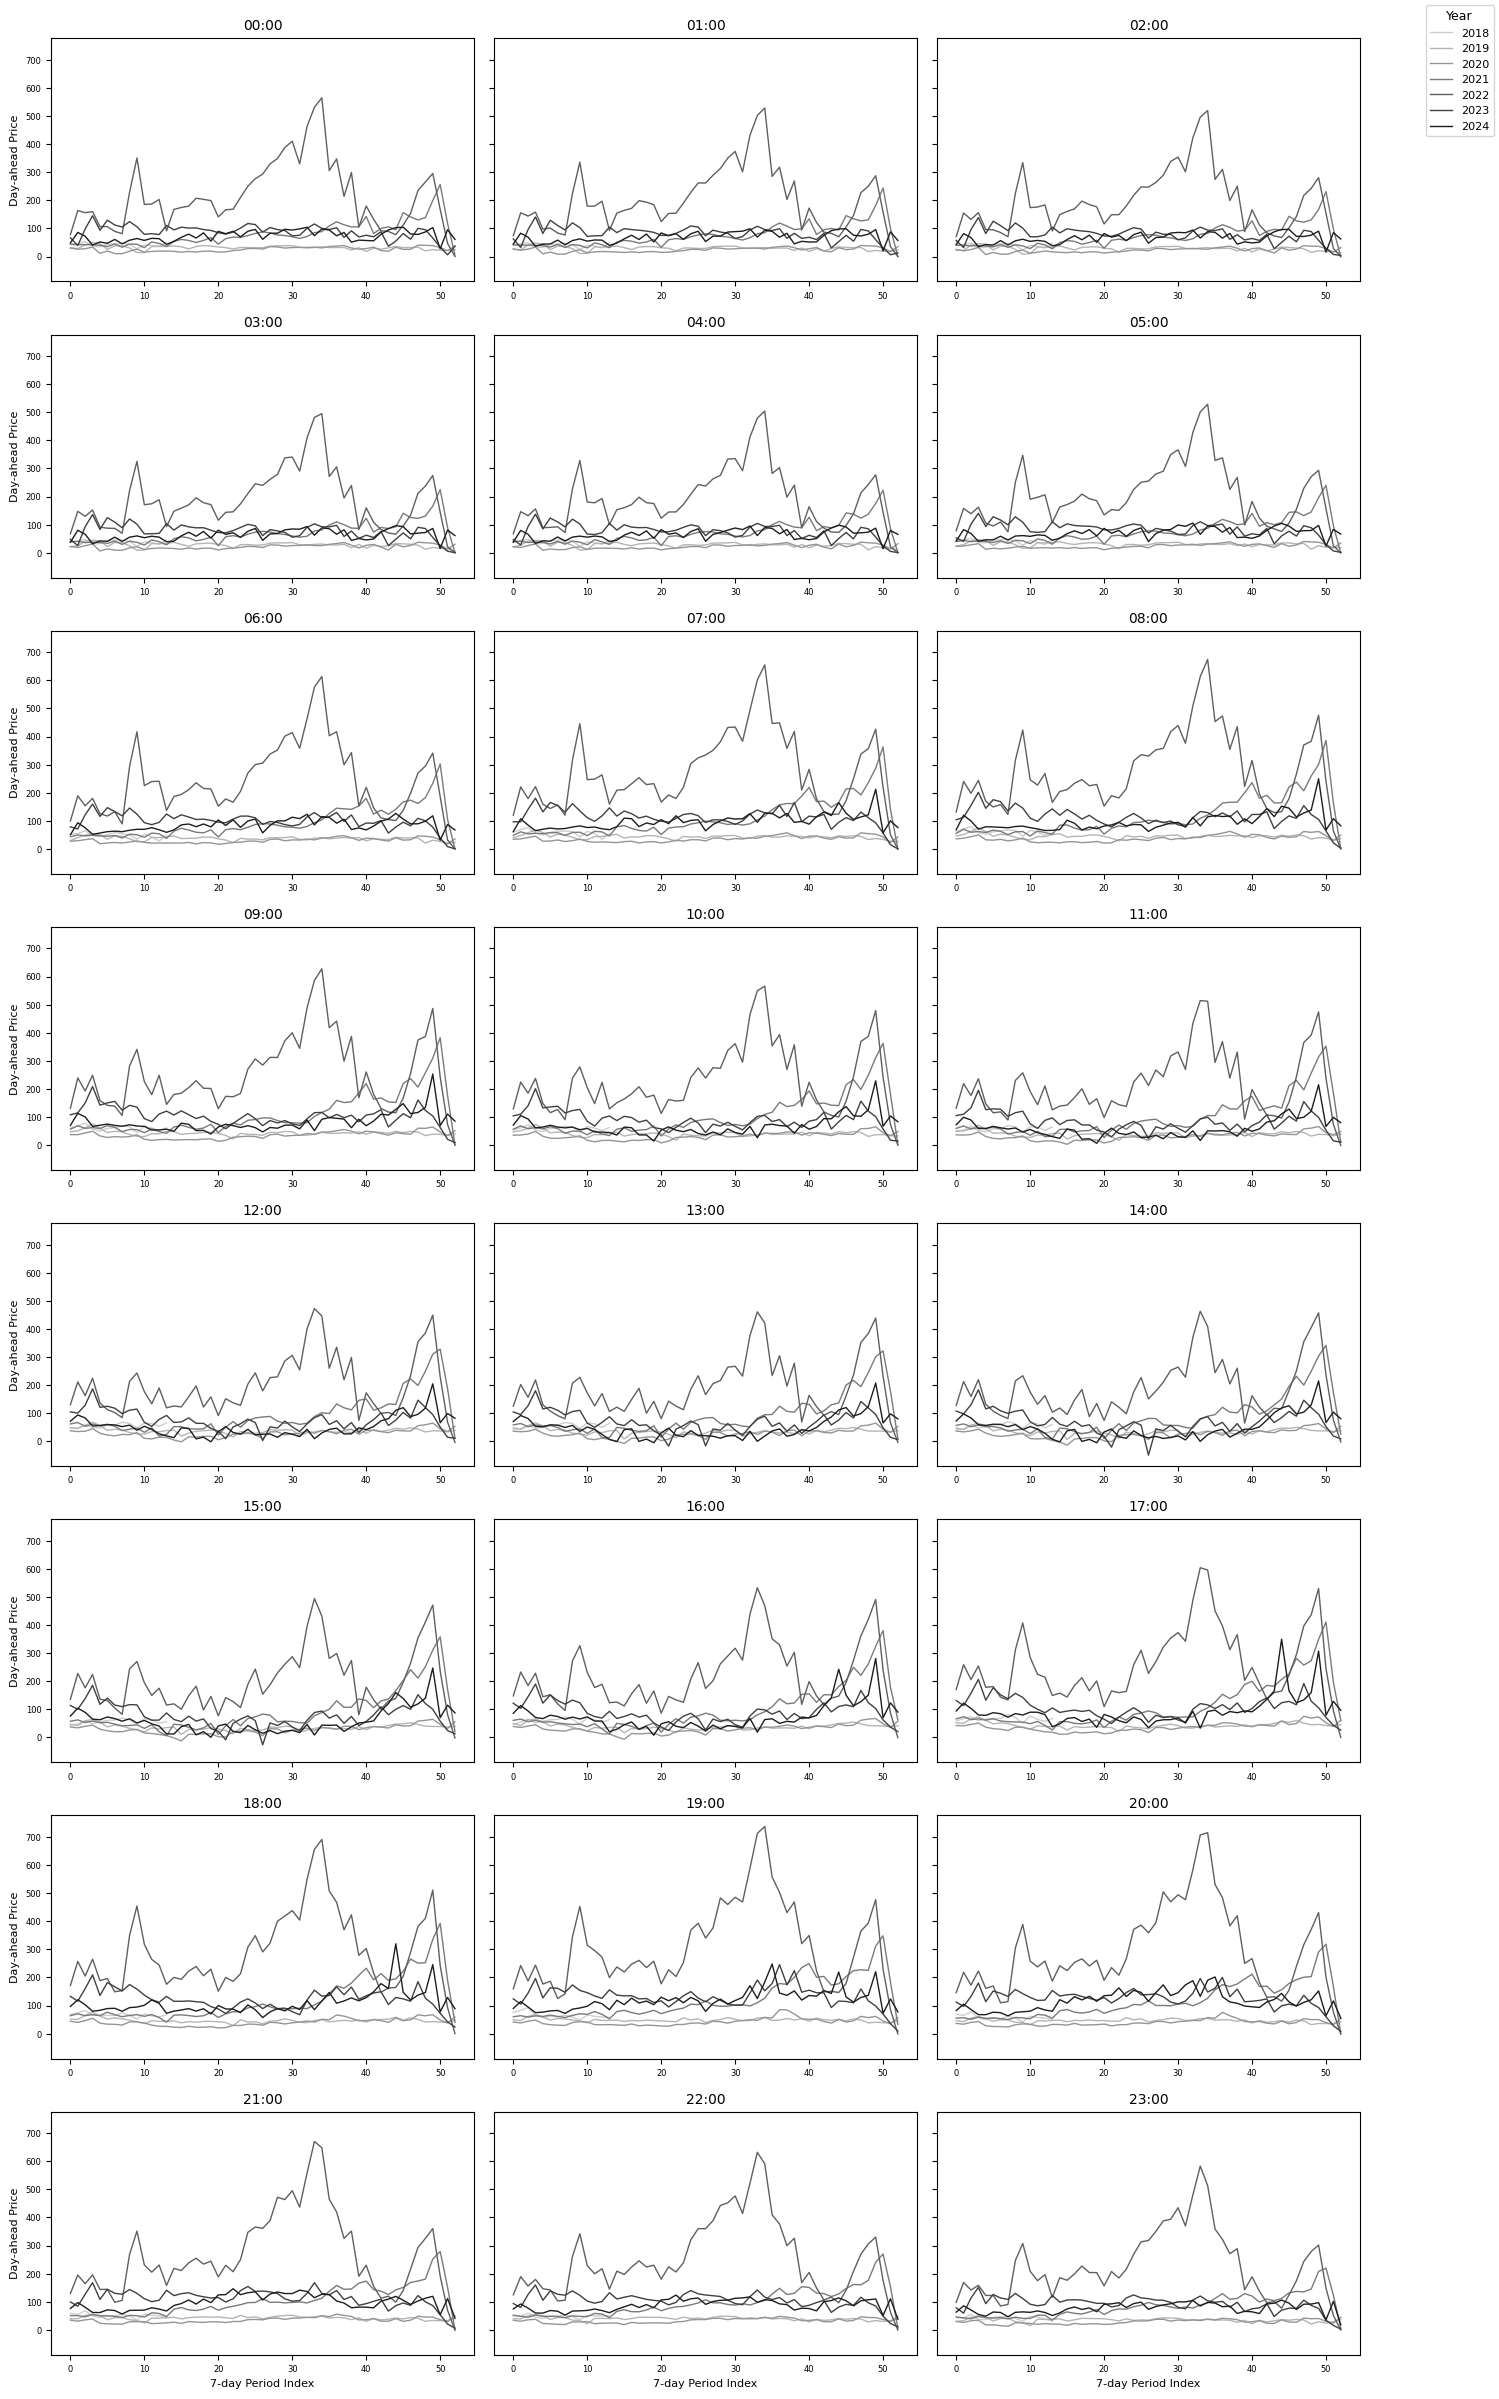

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_weekly_avg_by_hour(BZN: str, mode: str = 'prices'):
    """
    For the given BZN and mode ('prices' or 'loads'), produces an 8×3 grid of plots—
    one subplot for each hour of the day (00:00–23:00). In each subplot you get
    a gray‐scale line for each year; each point is the mean over a 7-day period
    of the price/load at that hour. The y-axis is shared across all panels.
    """
    # 1) sanity‐check & pick column
    assert mode in ('prices', 'loads'), "mode must be 'prices' or 'loads'"
    column = 'Day-ahead Price' if mode=='prices' else 'Actual Total Load (MW)'

    # 2) load & annotate
    df = pd.read_csv(f'data/{mode}/{BZN}.csv', parse_dates=['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['hour'] = df['timestamp'].dt.hour

    years = sorted(df['year'].unique())
    # grayscale palette
    colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(years)))

    # 3) set up 8×3 grid, share y‐axis
    fig, axes = plt.subplots(8, 3, figsize=(15, 24), sharey=True)
    axes = axes.flatten()

    for h in range(24):
        ax = axes[h]
        # for each year, take only that year & hour, then resample in 7D buckets
        for i, yr in enumerate(years):
            sub = df[(df['year']==yr) & (df['hour']==h)]
            # set timestamp index for resampling
            sub = sub.set_index('timestamp').sort_index()
            weekly = sub[column].resample('7D').mean()
            # x = week‐period index 0,1,2...
            x = np.arange(len(weekly))
            ax.plot(x, weekly.values, color=colors[i], linewidth=1, label=str(yr))

        # titles & labels
        ax.set_title(f"{h:02d}:00", fontsize=10)
        if h % 3 == 0:
            ax.set_ylabel(column, fontsize=8)
        if h // 3 == 7:
            ax.set_xlabel("7-day Period Index", fontsize=8)
        ax.tick_params(labelsize=6)

    # shared legend in the margin
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Year",
               loc="upper right", fontsize=8, title_fontsize=9)

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()


plot_weekly_avg_by_hour('DE')

In [ ]:
meth.plot_hours_below_daily_avg('ES')

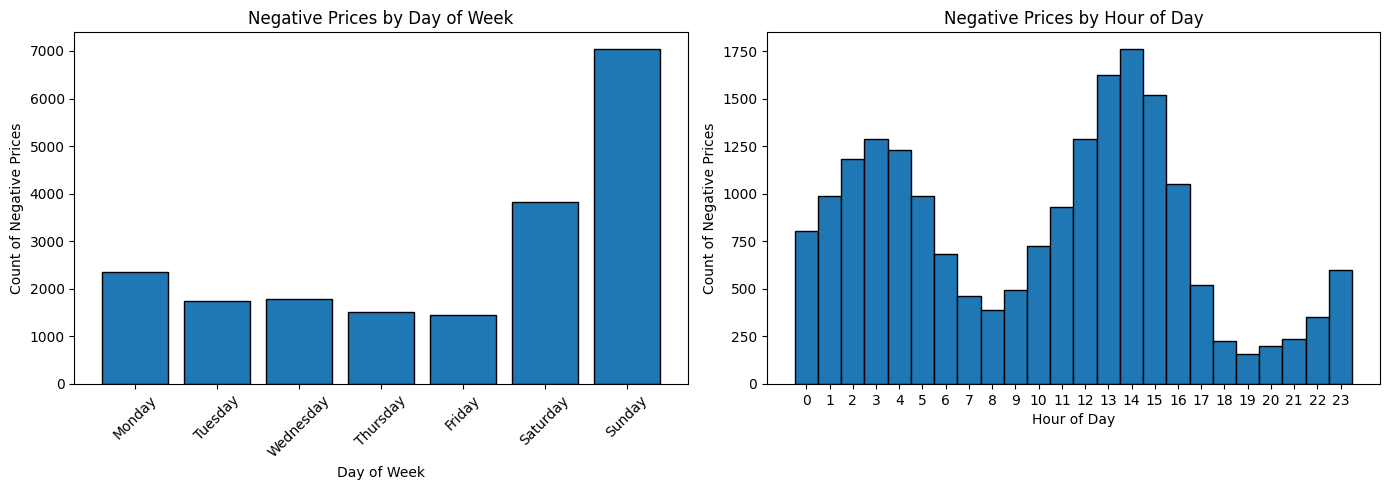

In [3]:
meth.plot_negative_price_histograms('data/prices')

In [ ]:
meth.plot_daily_averages(BZN = 'IT-north')
